# Tutorial 2: Label Transfer from a Reference Atlas to a Query Dataset

This tutorial shows how to use MIRACLE to transfer cell labels from an annotated reference atlas to a query dataset.
MIRACLE first maps reference and query cells into a shared joint latent space by continuing training from a reference checkpoint. A KNN classifier then uses the reference labels in that embedding to annotate query cells.

After completing the tutorial, you will be able to:

- Load a reference atlas and query MuData object.
- Continue MIRACLE training from a saved reference checkpoint.
- Build an `AnnData` object from the integrated joint latent embedding.
- Separate reference and query cells after integration.
- Transfer labels with KNN in the latent space, including an `Unknown` option.
- Visualize transferred labels and inspect a confusion matrix.

## Before You Start

This notebook expects the reference and query MuData files under `data/transfer_bm` and a trained reference checkpoint at `REFERENCE_MODEL_PATH`.

The reference MuData must provide `obs['label']`. The query MuData must provide `obs['true_label']` if you want to reproduce the evaluation section.

Training can run on GPU when CUDA is available. Adjust `CUDA_VISIBLE_DEVICES`, `BATCH_SIZE`, `QUERY_EPOCHS`, and the KNN settings for your hardware and dataset size.

## Workflow

```text
reference checkpoint + query MuData -> integrated MIRACLE model
joint latent embedding -> KNN label transfer -> confusion matrix
```


## Step 1: Import Dependencies

Import MIRACLE and the scientific Python packages used for model training, visualization, and label-transfer evaluation.


In [1]:
# Standard imports and project setup
import json
import os
import sys
from pathlib import Path

# Respect externally configured CUDA devices; otherwise default to GPU 1.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '1')

import torch
import matplotlib.pyplot as plt
import mudata as mu
import numpy as np
import pandas as pd
import scanpy as sc

from scmiracle.model import MIRACLE
from scmiracle.download_data import download as download_data

sc.settings.set_figure_params(figsize=(4, 4), dpi=110)


## Step 2: Configure Paths and Training Parameters

Define the input MuData files, reference checkpoint, output directory, and training parameters for the query-stage model.


In [2]:
# Define data, checkpoint, and output paths.

DATA_ROOT = os.path.join('data', 'atlas_transfer_mudata')
SAVE_DIR = os.path.join('results', 'atlas_transfer')

REFERENCE_MODEL_PATH = os.path.join(DATA_ROOT, 'model.pt')
QUERY_MODEL_DIR = os.path.join(SAVE_DIR, 'task2')
REFERENCE_H5MU = os.path.join(DATA_ROOT, 'reference_mdata.compact.h5mu')
QUERY_H5MU = os.path.join(DATA_ROOT, 'query_mdata.compact.h5mu')
LATENT_PATH = os.path.join(SAVE_DIR, 'latent_joint.npz')

required_files = [
    REFERENCE_H5MU,
    QUERY_H5MU,
    REFERENCE_MODEL_PATH
]

if not all(os.path.exists(path) for path in required_files):
    download_data('atlas_transfer_mudata', 'data')


os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(QUERY_MODEL_DIR, exist_ok=True)

BATCH_SIZE = 256
QUERY_EPOCHS = 2000
ACCELERATOR = 'gpu' if torch.cuda.is_available() else 'cpu'
DEVICES = 1
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Step 3: Load Reference and Query Data

The reference atlas provides labels for KNN training. The query dataset provides cells to annotate and, in this tutorial, `true_label` values for evaluation.


In [3]:
# Load the reference atlas and query dataset.
reference_mdata = mu.read_h5mu(REFERENCE_H5MU)
query_mdata = mu.read_h5mu(QUERY_H5MU)

print(reference_mdata)
print(query_mdata)

/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/io.py:408: UserWarning: The HDF5 file was not created by muon/mudata, we can't guarantee that everything will work correctly
  warn(
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var met

MuData object with n_obs × n_vars = 252789 × 59437
  obs:	'batch', 'label'
  uns:	'_miracle_replay_meta', '_scmidas', 'batch_colors', 'feat_dims', 'label_colors', 'neighbors', 'umap'
  obsm:	'X_umap', 'z'
  obsp:	'connectivities', 'distances'
  3 modalities
    rna:	243293 x 4044
      obs:	'batch'
      uns:	'mask_subset_0', 'mask_subset_1', 'mask_subset_10', 'mask_subset_11', 'mask_subset_12', 'mask_subset_13', 'mask_subset_14', 'mask_subset_17', 'mask_subset_18', 'mask_subset_19', 'mask_subset_2', 'mask_subset_20', 'mask_subset_21', 'mask_subset_22', 'mask_subset_23', 'mask_subset_24', 'mask_subset_25', 'mask_subset_26', 'mask_subset_27', 'mask_subset_28', 'mask_subset_29', 'mask_subset_3', 'mask_subset_30', 'mask_subset_31', 'mask_subset_32', 'mask_subset_33', 'mask_subset_4', 'mask_subset_5', 'mask_subset_6', 'mask_subset_7', 'mask_subset_8', 'mask_subset_9'
    adt:	188700 x 260
      obs:	'batch'
      uns:	'mask_subset_0', 'mask_subset_1', 'mask_subset_15', 'mask_subset_16', 'm

/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Inspect the Reference Atlas

Check the reference batches, labels, and modality dimensions before training. This confirms that the atlas metadata required for label transfer are available.


In [4]:
# Confirm reference label coverage and modality shapes.
print(reference_mdata.obs[['batch', 'label']].head())
for mod in reference_mdata.mod:
    print(mod, reference_mdata.mod[mod].shape)


                          batch                label
B0_CACCGGTAGACAAACG-1  subset_0  CD8+ Memory T cells
B0_CTCATTTAGAACAAGT-1  subset_0  CD4+ Memory T cells
B0_TAGCATATCGGTTCCT-1  subset_0           DP T cells
B0_TTGCACACACAGAAAC-1  subset_0   CD8+ Naive T cells
B0_TCCGCCATCAGCTAAC-1  subset_0   CD8+ Naive T cells
rna (243293, 4044)
adt (188700, 260)
atac (179143, 55133)


## Step 4: Continue Training from the Reference Checkpoint

The reference checkpoint stores the model weights and MIRACLE metadata needed for continual integration, including replay batch ordering.
`setup_continual` treats the reference atlas as replay data, adds the query MuData as the current task, and trains an updated model in the shared latent space.


In [5]:
# Show the checkpoint that will initialize the query-stage model.
print('continual checkpoint:', REFERENCE_MODEL_PATH)

continual checkpoint: data/atlas_transfer_mudata/model.pt


In [6]:
# Initialize from the reference checkpoint and add the query data as the current task.
miracle = MIRACLE(batch_size=BATCH_SIZE, save_model_path=QUERY_MODEL_DIR)
miracle.setup_continual(
    current_mdata=query_mdata,
    replay_mdata=reference_mdata,
    prev_model_dir=REFERENCE_MODEL_PATH,
)
miracle.train(max_epochs=QUERY_EPOCHS, accelerator=ACCELERATOR, devices=DEVICES)
miracle.save(QUERY_MODEL_DIR, overwrite=True)

latent_joint = miracle.get_latent_representation(kind='joint')
merged_mdata = miracle.model._mdata
batch_series = MIRACLE.get_obs_series(merged_mdata, 'batch').reindex(merged_mdata.obs_names).astype(str)
np.savez_compressed(LATENT_PATH, latent=latent_joint)
print('Integrated latent shape:', latent_joint.shape)


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LO

Epoch 1999: 100%|██████████| 84/84 [00:06<00:00, 13.17it/s, v_num=5, loss_/recon_loss_step=7.82e+3, loss_/kld_loss_step=132.0, loss_/consistency_loss_step=14.00, loss/net_step=7.02e+3, loss/dsc_step=253.0, loss_/recon_loss_epoch=1.23e+4, loss_/kld_loss_epoch=134.0, loss_/consistency_loss_epoch=21.20, loss/net_epoch=7.04e+3, loss/dsc_epoch=264.0]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 84/84 [00:07<00:00, 11.77it/s, v_num=5, loss_/recon_loss_step=7.82e+3, loss_/kld_loss_step=132.0, loss_/consistency_loss_step=14.00, loss/net_step=7.02e+3, loss/dsc_step=253.0, loss_/recon_loss_epoch=1.23e+4, loss_/kld_loss_epoch=134.0, loss_/consistency_loss_epoch=21.20, loss/net_epoch=7.04e+3, loss/dsc_epoch=264.0]
Integrated latent shape: (263460, 34)


## Step 5: Prepare the Latent Space for Label Transfer

After continual training, build an `AnnData` object from the joint latent embedding.
This evaluation object stores batch labels, reference annotations, and query truth labels used for plotting and KNN-based transfer.


### Create an AnnData View of the Joint Embedding

Use the first 32 latent dimensions for UMAP visualization and KNN label transfer.
The `AnnData` object is an analysis view only; model training was completed in the previous step.


In [7]:
sc.settings.set_figure_params(figsize=(3, 3), dpi=110)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score
from joblib import Parallel, delayed
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.AnnData(latent_joint[:, :32])
adata.obs_names = batch_series.index
adata.obs['batch'] = batch_series
adata.obs['reference label'] = reference_mdata.obs['label']
adata.obs['query label'] = query_mdata.obs['true_label']

sc.pp.neighbors(adata)
sc.tl.umap(adata)


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Split Reference and Query Cells, Then Run KNN

Separate cells by batch so reference and query subsets can be handled explicitly.
Reference cells provide known labels. Query cells are also assigned a temporary `Unknown` label so high-uncertainty cells can be rejected instead of forced into a reference class.
Tune `n_neighbors` and `unknown_thresh` for each dataset.


Example 'Unknown' probabilities for query cells: [0.93 0.07 0.55 0.28 0.69]


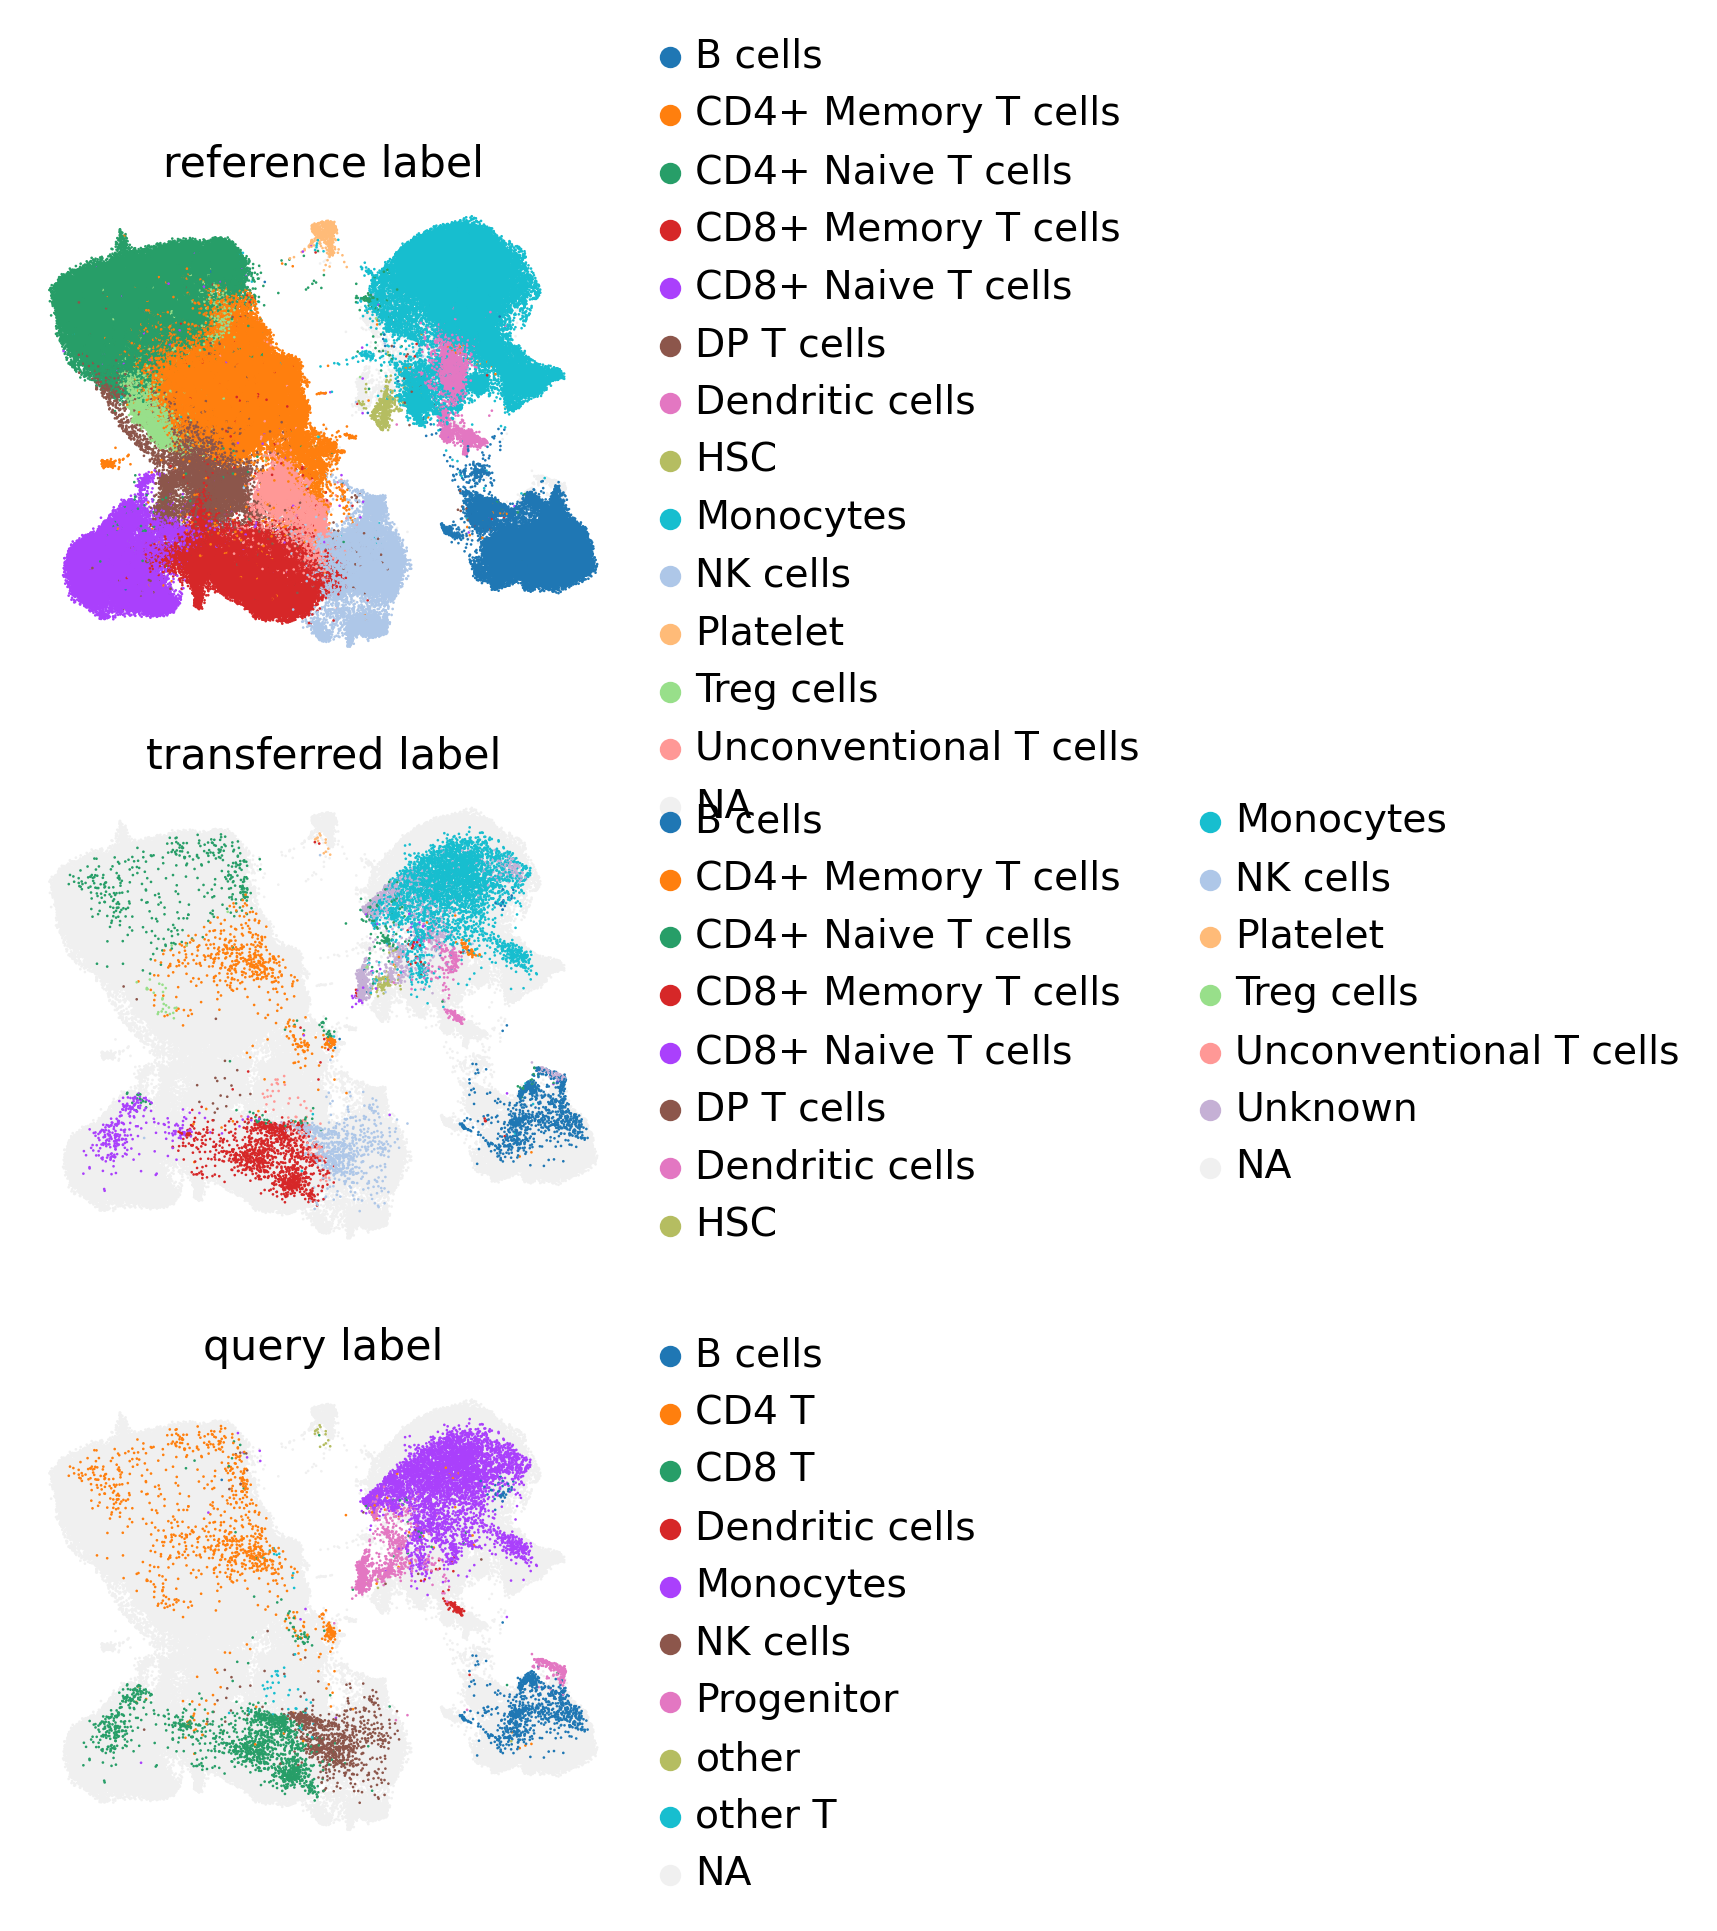

In [8]:
query_batches = set(query_mdata.obs['batch'].astype(str).unique())
adata_ref = adata[~adata.obs['batch'].isin(query_batches)].copy()
adata_query = adata[adata.obs['batch'].isin(query_batches)].copy()

label_ref = adata_ref.obs['reference label'].astype(str).values
label_query_unknown = np.array(['Unknown'] * adata_query.n_obs)

X_train = np.vstack([adata_ref.X, adata_query.X])
label_train = np.concatenate([label_ref, label_query_unknown])
X_query = adata_query.X

knn = KNeighborsClassifier(n_neighbors=100, weights='uniform')
knn.fit(X_train, label_train)

def predict_batch(X, knn_model):
    return knn_model.predict(X)

def predict_prob_batch(X, knn_model):
    return knn_model.predict_proba(X)

def knn_predict_par(X, knn_model, num_cores):
    X_batches = np.array_split(X, num_cores)
    with Parallel(n_jobs=num_cores, backend='threading') as parallel:
        results = parallel(delayed(predict_batch)(X_batch, knn_model) for X_batch in X_batches)
    return np.concatenate(results)

def knn_predict_prob_par(X, knn_model, num_cores):
    X_batches = np.array_split(X, num_cores)
    with Parallel(n_jobs=num_cores, backend='threading') as parallel:
        results = parallel(delayed(predict_prob_batch)(X_batch, knn_model) for X_batch in X_batches)
    return np.concatenate(results)

num_cores = 1
prob_pred = knn_predict_prob_par(X_query, knn, num_cores)
prob_pred_unknown = prob_pred[:, np.where(knn.classes_ == 'Unknown')[0][0]]

print(f"Example 'Unknown' probabilities for query cells: {prob_pred_unknown[:5]}")

unknown_thresh = 0.85
predict_label = knn.classes_[np.argmax(prob_pred[:, :-1], axis=1)]
predict_label[prob_pred_unknown > unknown_thresh] = 'Unknown'

adata.obs['transferred label'] = pd.Series(pd.NA, index=adata.obs_names, dtype='object')
adata.obs.loc[adata_query.obs_names, 'transferred label'] = predict_label.astype(str)

sc.pl.umap(
    adata,
    color=['reference label', 'transferred label', 'query label'],
    na_color='#F0F0F0',
    size=3,
    frameon=False,
    ncols=1,
)
plt.show()

## Step 6: Evaluate the Transferred Labels

Summarize the transferred labels with a confusion matrix.
This compares predicted query annotations with the provided query truth labels and makes common error patterns easier to inspect.


In [9]:
all_kinds = np.unique(np.concatenate([adata_query.obs['query label'].astype(str).values, predict_label]))
conf_matrix_df = pd.DataFrame(
    confusion_matrix(adata_query.obs['query label'].astype(str).values, predict_label, labels=all_kinds),
    index=all_kinds,
    columns=all_kinds,
)
conf_matrix_df

,B cells,CD4 T,CD4+ Memory T cells,CD4+ Naive T cells,CD8 T,CD8+ Memory T cells,CD8+ Naive T cells,DP T cells,Dendritic cells,HSC,Monocytes,NK cells,Platelet,Progenitor,Treg cells,Unconventional T cells,Unknown,other,other T
B cells,856,0,0,19,0,4,0,0,0,0,29,1,0,0,0,0,1,0,0
CD4 T,4,0,516,409,0,25,4,10,0,1,18,8,0,0,29,0,0,0,0
CD4+ Memory T cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CD4+ Naive T cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CD8 T,0,0,40,36,0,1101,305,2,0,0,8,26,0,0,0,11,21,0,0
CD8+ Memory T cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CD8+ Naive T cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
DP T cells,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dendritic cells,1,0,0,0,0,0,0,0,90,0,4,0,0,0,0,0,2,0,0
HSC,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
